In [2]:
#Loading and Preprocessing the Dataset
from datasets import load_dataset
from transformers import AutoTokenizer

# Load the specific model and dataset
model_id = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Load the dataset
dataset = load_dataset("ktiyab/sustainable-fashion", split="train")

# Split into train and validation (80/20)
dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset["train"]
valid_dataset = dataset["test"]

# Preprocessing function for Sequence-to-Sequence
def preprocess_function(examples):
    # Add a prompt to help the model understand the task
    inputs = ["question: " + q for q in examples["input_text"]]
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Setup the targets (answers)
    labels = tokenizer(text_target=examples["output_text"], max_length=128, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Apply the preprocessing
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_valid = valid_dataset.map(preprocess_function, batched=True)

print("Dataset successfully tokenized!")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

sustainable_fashion_finetune_data.json:   0%|          | 0.00/27.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40305 [00:00<?, ? examples/s]

Map:   0%|          | 0/32244 [00:00<?, ? examples/s]

Map:   0%|          | 0/8061 [00:00<?, ? examples/s]

Dataset successfully tokenized!


In [3]:
#Sanity Check
print("--- RAW DATA CHECK ---")
# Let's see if the raw dataset actually has the text we want
sample_raw = train_dataset[0]
print(f"Raw Keys Found: {sample_raw.keys()}")
print(f"Instruction text: {sample_raw.get('instruction', 'MISSING!')[:100]}...")
print(f"Response text: {sample_raw.get('response', 'MISSING!')[:100]}...\n")

print("--- TOKENIZED DATA CHECK ---")
# Let's verify the preprocessing function actually did its job
sample_tokenized = tokenized_train[0]
print(f"Tokenized Keys: {sample_tokenized.keys()}")
print(f"Are there input_ids? {'Yes' if 'input_ids' in sample_tokenized else 'No'}")
print(f"Are there labels? {'Yes' if 'labels' in sample_tokenized else 'No'}\n")

print("--- MODEL VISION CHECK ---")
# Let's decode the numbers back into text to see EXACTLY what the model reads!
decoded_inputs = tokenizer.decode(sample_tokenized["input_ids"], skip_special_tokens=False)
print(f"What the model READS (Inputs):\n{decoded_inputs}\n")

# To decode labels, we have to temporarily swap the -100s back to pad tokens
import numpy as np
safe_labels = np.where(np.array(sample_tokenized["labels"]) != -100, sample_tokenized["labels"], tokenizer.pad_token_id)
decoded_labels = tokenizer.decode(safe_labels, skip_special_tokens=False)
print(f"What the model MUST PREDICT (Labels):\n{decoded_labels}")

--- RAW DATA CHECK ---
Raw Keys Found: dict_keys(['input_text', 'output_text'])
Instruction text: MISSING!...
Response text: MISSING!...

--- TOKENIZED DATA CHECK ---
Tokenized Keys: dict_keys(['input_text', 'output_text', 'input_ids', 'attention_mask', 'labels'])
Are there input_ids? Yes
Are there labels? Yes

--- MODEL VISION CHECK ---
What the model READS (Inputs):
question: I want to wear dresses as a staple but need them to work for formal and casual settings. Any suggestions for timeless dress styles?</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad

In [4]:
#Model and Evaluation Metrics
import evaluate
import numpy as np
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer

# Load the Sequence-to-Sequence model
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    #Replacing -100 in predictions with pad_token_id
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)

    # Decode predictions back into readable text
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # Sanitize labels (already had this, but keeping it clean)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Compute ROUGE score
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v * 100, 4) for k, v in result.items()}

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [5]:
# Training Loop
training_args = Seq2SeqTrainingArguments(
    output_dir="./sustainable-fashion-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5, #adjusted to prevent nan loss
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=4,
    predict_with_generate=True,
    load_best_model_at_end=True,
    report_to="none", #Prevents some notebook tracking errors
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    processing_class=tokenizer, # or use tokenizer=tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.217980,2.014728,15.889500,2.955300,11.873500,11.874600
2,2.114462,1.924519,16.575000,3.326000,12.355400,12.358700
3,2.044496,1.884745,16.737000,3.446900,12.436800,12.435200
4,2.038507,1.872521,16.856200,3.511700,12.523800,12.525200


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=16124, training_loss=2.181538978601265, metrics={'train_runtime': 4614.2724, 'train_samples_per_second': 27.952, 'train_steps_per_second': 3.494, 'total_flos': 5993853433675776.0, 'train_loss': 2.181538978601265, 'epoch': 4.0})

In [6]:
# Perform Evaluation
metrics = trainer.evaluate(max_length=64) # Changed from generation_max_length
print("\n--- FINAL EVALUATION METRICS ---")
print(metrics)

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum
2.038507,1.872521,4,28.411200,5.511300,18.298800,18.293500



--- FINAL EVALUATION METRICS ---
{'eval_loss': 1.8725212812423706, 'eval_rouge1': 28.4112, 'eval_rouge2': 5.5113, 'eval_rougeL': 18.2988, 'eval_rougeLsum': 18.2935}


In [7]:
#Saving the Final Model and Tokenizer
save_directory = "./final-sustainable-fashion-model"

# Save the model's weights
model.save_pretrained(save_directory)

# Save the tokenizer's vocabulary
tokenizer.save_pretrained(save_directory)

print(f"Success! Model and tokenizer securely saved to: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Success! Model and tokenizer securely saved to: ./final-sustainable-fashion-model


In [11]:
#Test the Fine-Tuned Model (Batch Inference)

#Provide a list of 5 questions
my_questions = [
    "What are the most eco-friendly fabrics I should look for when I want to buy an outfit for the summer?",
    "How can I style my maxi dress when going on a casual walk?",
    "What fashion choices would you suggest for a plain white shirt and a brown pants for men",
    "Does a polo shirt go with bell bottom jeans?",
    "Do other natural fabrics like pineapple fabric considered sustainable to be sewn for fashion",
    "What is the best way to dispose of old clothes that are torn or unwearable?",
    "Why is fast fashion considered harmful to the environment?",
    "How should I wash my clothes to make them last longer and save water?"
]

#Format them exactly like the training data
formatted_inputs = ["question: " + q for q in my_questions]

#Tokenize the batch (padding=True is required for batching)
inputs = tokenizer(
    formatted_inputs,
    return_tensors="pt",
    padding=True,
    truncation=True
).to(model.device)

#Generate the predictions for all questions at once
outputs = model.generate(
    **inputs,
    max_length=64,
    num_beams=4,
    early_stopping=True
)

#Decode and print the results
print("--- MODEL INFERENCE RESULTS ---\n")

for i, (question, output) in enumerate(zip(my_questions, outputs)):
    predicted_answer = tokenizer.decode(output, skip_special_tokens=True)

    print(f"QUESTION {i+1}:")
    print(question)
    print("\nMODEL'S SUSTAINABLE ADVICE:")
    print(predicted_answer)
    print("\n" + "-"*60 + "\n")

--- MODEL INFERENCE RESULTS ---

QUESTION 1:
What are the most eco-friendly fabrics I should look for when I want to buy an outfit for the summer?

MODEL'S SUSTAINABLE ADVICE:
Look for natural fibers like organic cotton, linen, and linen blends that can be repurposed for cooler months. Look for organic cotton or bamboo blends that can be repurposed for warmer months. Look for breathable, eco-friendly fabrics like organic cotton, bamboo, or Tencel

------------------------------------------------------------

QUESTION 2:
How can I style my maxi dress when going on a casual walk?

MODEL'S SUSTAINABLE ADVICE:
Opt for a mid-length or slightly tapered maxi dress in a neutral color—black, navy, or navy—that can be dressed up or down. Pair it with a tailored blazer or a structured blazer for a relaxed vibe. Pair it with a

------------------------------------------------------------

QUESTION 3:
What fashion choices would you suggest for a plain white shirt and a brown pants for men

MODEL'S 

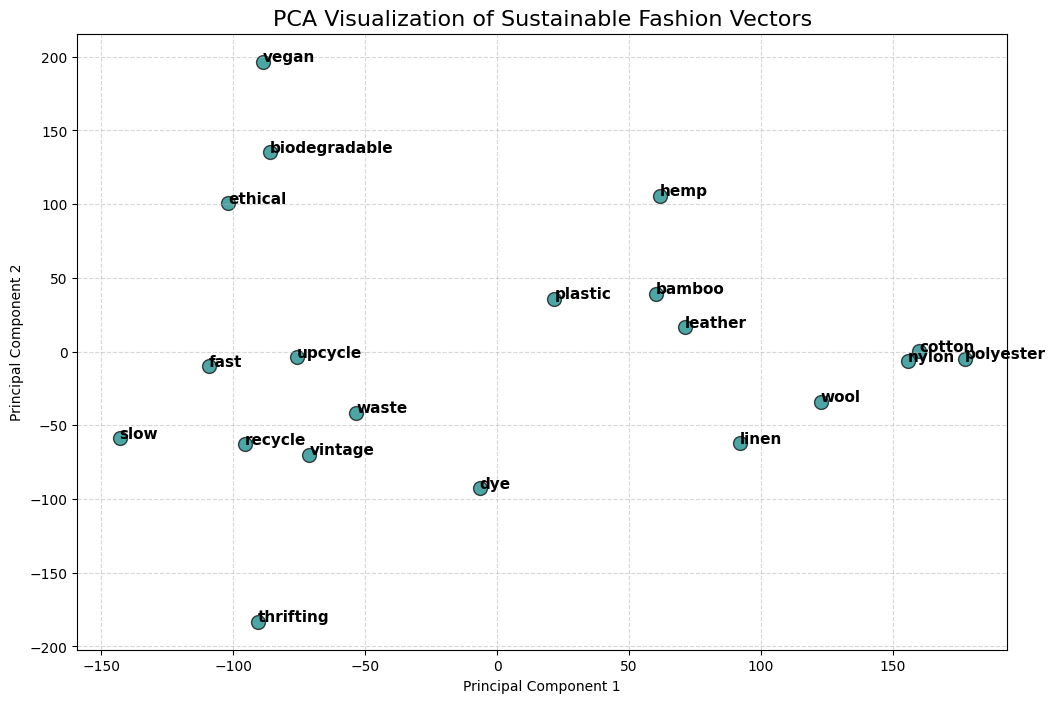

In [9]:
#PCA Graph Visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch

# Generate 20 known words related to the domain
vocab = [
    "cotton", "polyester", "vintage", "thrifting", "fast", "slow",
    "linen", "hemp", "upcycle", "biodegradable", "plastic", "nylon",
    "wool", "ethical", "vegan", "leather", "bamboo", "dye", "recycle", "waste"
]

# Extract their vectors from our fine-tuned model
inputs = tokenizer(vocab, return_tensors="pt", padding=True).to(model.device)
with torch.no_grad():
    # We grab the embeddings (vectors) of the very first token of each word
    embeddings = model.get_input_embeddings()(inputs.input_ids[:, 0]).cpu().numpy()

#Apply PCA to squish 512 dimensions down to 2 dimensions (X and Y)
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embeddings)

#Plot the graph
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='teal', s=100, edgecolors='black', alpha=0.7)

# Add the word labels to each dot
for i, word in enumerate(vocab):
    plt.annotate(word, (vectors_2d[i, 0] + 0.02, vectors_2d[i, 1] + 0.02), fontsize=11, fontweight='bold')

plt.title("PCA Visualization of Sustainable Fashion Vectors", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()